In [41]:
import numpy as np
from matplotlib import pyplot as plt

In [37]:
M = np.random.randint(0,2, size=(4,4))
M

array([[1, 1, 1, 1],
       [0, 1, 1, 0],
       [1, 1, 0, 1],
       [0, 0, 1, 1]])

In [35]:
idx = M != 1
idx

array([[False, False,  True,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True]])

In [41]:
np.delete(M,[[3,3]])

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1])

In [15]:
np.where(M==1)

(array([1, 1, 2, 2, 3, 3]), array([2, 3, 1, 3, 2, 3]))

In [17]:
np.sum(M==1, axis=1)

array([0, 2, 2, 2])

In [25]:
a = np.array([[0,1,1],[0,1,1],[0,0,0]])


In [44]:
n = np.max(np.sum(a==1, axis=0))
new = np.delete(a, np.where(a.flatten()==0)).reshape((n,n))

In [45]:
new

array([[1, 1],
       [1, 1]])

In [5]:
np.where(a==0)

NameError: name 'np' is not defined

In [48]:
def T_k(k,x):
    return np.cos(k*np.arccos(x))

def tau(n,x):
    state = np.zeros(shape=(2**n), dtype=np.float64)
    for (i,_) in enumerate(state):
        if i==0:
            factor = 1.00/(2**(n/2))
        else:
            factor = 1.00/(2**((n-1)/2))
        state[i] = factor*T_k(i,x)
    return state

In [49]:
n = 4
j = np.linspace(0,2**n-1,2**n)
x = np.cos(np.pi*(2*j+1)/2**(n+1))
x

array([ 0.99518473,  0.95694034,  0.88192126,  0.77301045,  0.63439328,
        0.47139674,  0.29028468,  0.09801714, -0.09801714, -0.29028468,
       -0.47139674, -0.63439328, -0.77301045, -0.88192126, -0.95694034,
       -0.99518473])

In [50]:
s=tau(n,x[1])
s

array([ 0.25      ,  0.3383295 ,  0.2939689 ,  0.2242919 ,  0.13529903,
        0.03465429, -0.06897484, -0.16666391, -0.25      , -0.31180625,
       -0.34675996, -0.35185093, -0.32664074, -0.27330047, -0.19642374,
       -0.10263113])

In [52]:
def ortho(n,x0,x1):
    return np.abs(tau(n,x0).T@tau(n,x1))**2

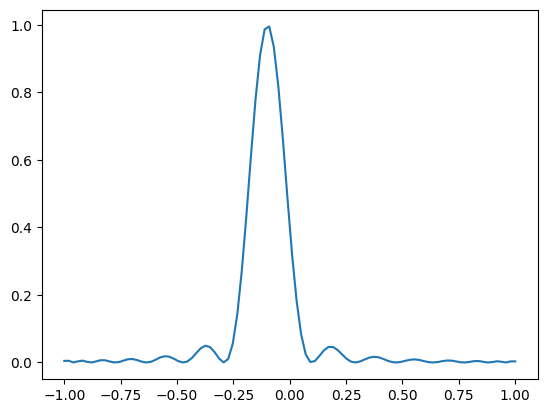

In [58]:
x1 = np.linspace(-1,1,100)
y = np.zeros_like(x1)
for i in range(len(x1)):
    y[i] = ortho(n,x[8],x1[i])
plt.plot(x1,y)

In [51]:
np.abs(tau(n,x[7]).T@tau(n,x1[10]))**2

np.float64(0.0017454942435862822)

In [62]:
for i in x:
    print(ortho(n,x[8],i))

2.565820168409895e-31
1.5643365973285323e-31
4.0492677080741634e-32
6.591495234665315e-32
1.509929076399593e-31
2.7083389842945504e-31
6.933347799794049e-33
1.4914401489334754e-30
0.9999999999999991
1.7017516988605616e-30
4.3333423748712807e-32
7.765831018255432e-31
1.2037062152420224e-31
9.437056727497456e-33
4.911602840673548e-31
1.232595164407831e-32


In [2]:
import numpy as np
from matplotlib import pyplot as plt
import random


In [3]:
# Generate a random fourier series
def fourier_series(x, coeffs):
    result = np.zeros_like(x)
    for k, c in enumerate(coeffs):
        result += c * np.cos(k * x)
    return result

In [14]:
# Generate a random fourier series
def series(x, freqs):
    result = 0
    for f in freqs:
        result += np.cos(f * x)
    return result/result.max()

In [15]:
freqs=random.sample(range(10), 5)


In [16]:
x = np.linspace(0, 4*np.pi, 100)
y = series(x, freqs)

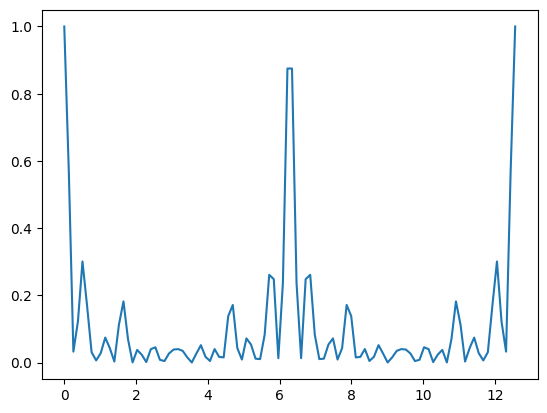

In [19]:
plt.plot(x,y**2)

In [8]:
y2 = 2*np.mean(y)-y

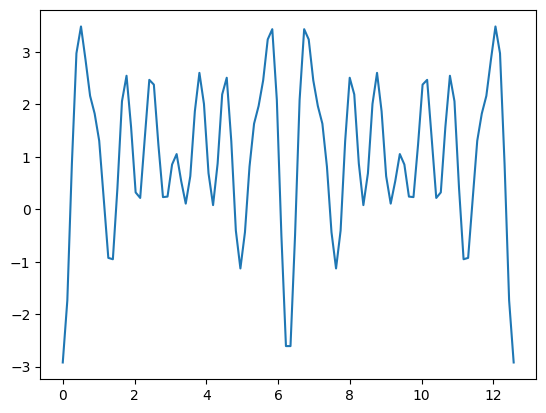

In [9]:
plt.plot(x,y2)

In [10]:
print(np.mean(y))
print(np.mean(y2))

1.0400000000000005
1.0400000000000005


In [24]:
theta = np.pi/4
a = 1
Mat = np.array([[np.cos(theta),-1j*a*np.sin(theta)],[-1j*1/a*np.sin(theta),np.cos(theta)]])
R = Mat@Mat.conj().T

In [25]:
R

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])